# Notebook 01 — Análisis Exploratorio de Datos (EDA)
**TFM:** Detección de fraude en tarjetas de crédito mediante aprendizaje automático supervisado: comparativa de modelos y evaluación de generalización entre dominios

**Instrucciones:**
1. Descarga el dataset ULB desde Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
2. Coloca el archivo `creditcard.csv` en la misma carpeta que este notebook
3. Ejecuta todas las celdas en orden (Kernel > Restart & Run All)

**Librerías necesarias:**
```
pip install pandas numpy matplotlib seaborn scikit-learn scipy
```


In [5]:
# ── INSTALACIÓN DE DEPENDENCIAS (ejecutar solo si es necesario) ──
!pip install pandas numpy matplotlib seaborn scikit-learn scipy


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
# ── IMPORTACIONES ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
sns.set_palette('husl')

print("✅ Librerías cargadas correctamente")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  seaborn {sns.__version__}")


✅ Librerías cargadas correctamente
  pandas  3.0.3
  numpy   2.4.6
  seaborn 0.13.2


## 1. Carga y vista general del dataset

In [7]:
# ── CARGA DEL DATASET ─────────────────────────────────────────────────────
df = pd.read_csv('creditcard.csv')

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria:     {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("Primeras filas:")
df.head()


Dimensiones: 284,807 filas × 31 columnas
Memoria:     70.6 MB

Primeras filas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# ── TIPOS DE DATOS Y VALORES FALTANTES ───────────────────────────────────
print("=== TIPOS Y VALORES FALTANTES ===")
info = pd.DataFrame({
    'Tipo'      : df.dtypes,
    'No nulos'  : df.notnull().sum(),
    'Nulos'     : df.isnull().sum(),
    '% Nulos'   : (df.isnull().sum() / len(df) * 100).round(3)
})
print(info.to_string())
print()
print(f"✅ Valores faltantes totales: {df.isnull().sum().sum()}")


=== TIPOS Y VALORES FALTANTES ===
           Tipo  No nulos  Nulos  % Nulos
Time    float64    284807      0      0.0
V1      float64    284807      0      0.0
V2      float64    284807      0      0.0
V3      float64    284807      0      0.0
V4      float64    284807      0      0.0
V5      float64    284807      0      0.0
V6      float64    284807      0      0.0
V7      float64    284807      0      0.0
V8      float64    284807      0      0.0
V9      float64    284807      0      0.0
V10     float64    284807      0      0.0
V11     float64    284807      0      0.0
V12     float64    284807      0      0.0
V13     float64    284807      0      0.0
V14     float64    284807      0      0.0
V15     float64    284807      0      0.0
V16     float64    284807      0      0.0
V17     float64    284807      0      0.0
V18     float64    284807      0      0.0
V19     float64    284807      0      0.0
V20     float64    284807      0      0.0
V21     float64    284807      0      0.0


In [9]:
# ── ESTADÍSTICAS DESCRIPTIVAS GENERALES ──────────────────────────────────
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
desc = df.describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'].abs() * 100).round(1)
print(desc[['mean','std','min','25%','50%','75%','max','CV (%)']].to_string())


=== ESTADÍSTICAS DESCRIPTIVAS ===
                mean           std         min           25%           50%            75%            max        CV (%)
Time    9.481386e+04  47488.145955    0.000000  54201.500000  84692.000000  139320.500000  172792.000000  5.010000e+01
V1      1.175161e-15      1.958696  -56.407510     -0.920373      0.018109       1.315642       2.454930  1.666747e+17
V2      3.384974e-16      1.651309  -72.715728     -0.598550      0.065486       0.803724      22.057729  4.878349e+17
V3     -1.379537e-15      1.516255  -48.325589     -0.890365      0.179846       1.027196       9.382558  1.099105e+17
V4      2.094852e-15      1.415869   -5.683171     -0.848640     -0.019847       0.743341      16.875344  6.758800e+16
V5      1.021879e-15      1.380247 -113.743307     -0.691597     -0.054336       0.611926      34.801666  1.350695e+17
V6      1.494498e-15      1.332271  -26.160506     -0.768296     -0.274187       0.398565      73.301626  8.914505e+16
V7     -5.6203

## 2. Distribución de clases (desbalance)

=== DISTRIBUCIÓN DE CLASES ===
  Legítimas  (0):  284,315  (99.827%)
  Fraudulentas(1):      492  (0.173%)
  Ratio desbalance: 578:1


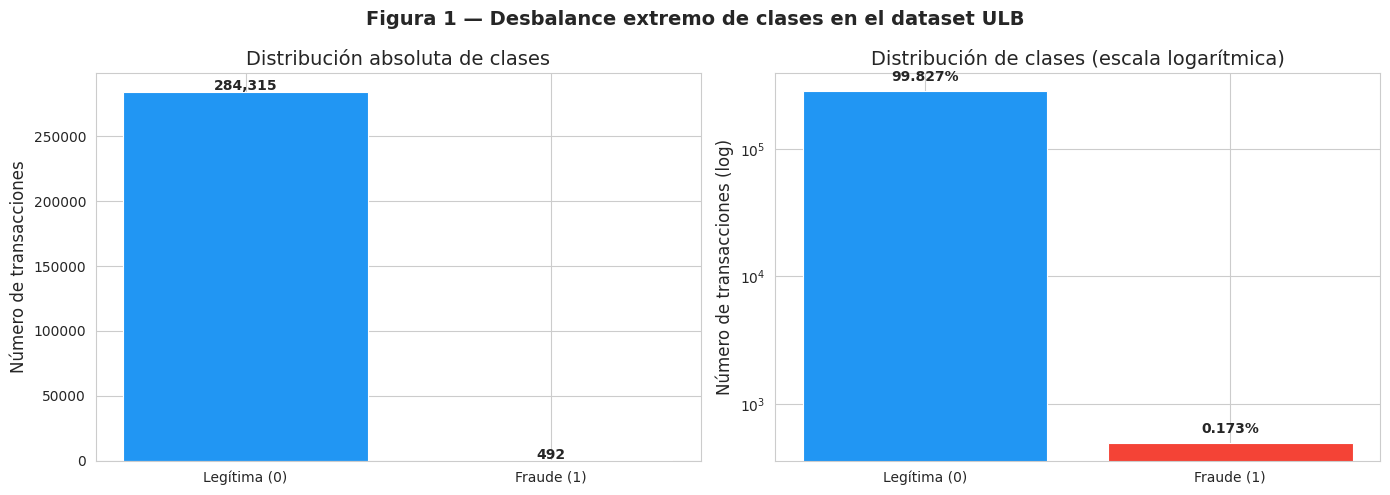

✅ Figura guardada: fig01_distribucion_clases.png


In [10]:
# ── DISTRIBUCIÓN DE CLASES ────────────────────────────────────────────────
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print("=== DISTRIBUCIÓN DE CLASES ===")
print(f"  Legítimas  (0): {class_counts[0]:>8,}  ({class_pct[0]:.3f}%)")
print(f"  Fraudulentas(1): {class_counts[1]:>8,}  ({class_pct[1]:.3f}%)")
print(f"  Ratio desbalance: {class_counts[0]/class_counts[1]:.0f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
axes[0].bar(['Legítima (0)', 'Fraude (1)'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribución absoluta de clases')
axes[0].set_ylabel('Número de transacciones')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Escala logarítmica para ver ambas barras
axes[1].bar(['Legítima (0)', 'Fraude (1)'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', linewidth=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Distribución de clases (escala logarítmica)')
axes[1].set_ylabel('Número de transacciones (log)')
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v * 1.2, f'{class_pct.values[i]:.3f}%', ha='center', fontweight='bold')

plt.suptitle('Figura 1 — Desbalance extremo de clases en el dataset ULB', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig01_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: fig01_distribucion_clases.png")


## 3. Distribución temporal (variable Time)

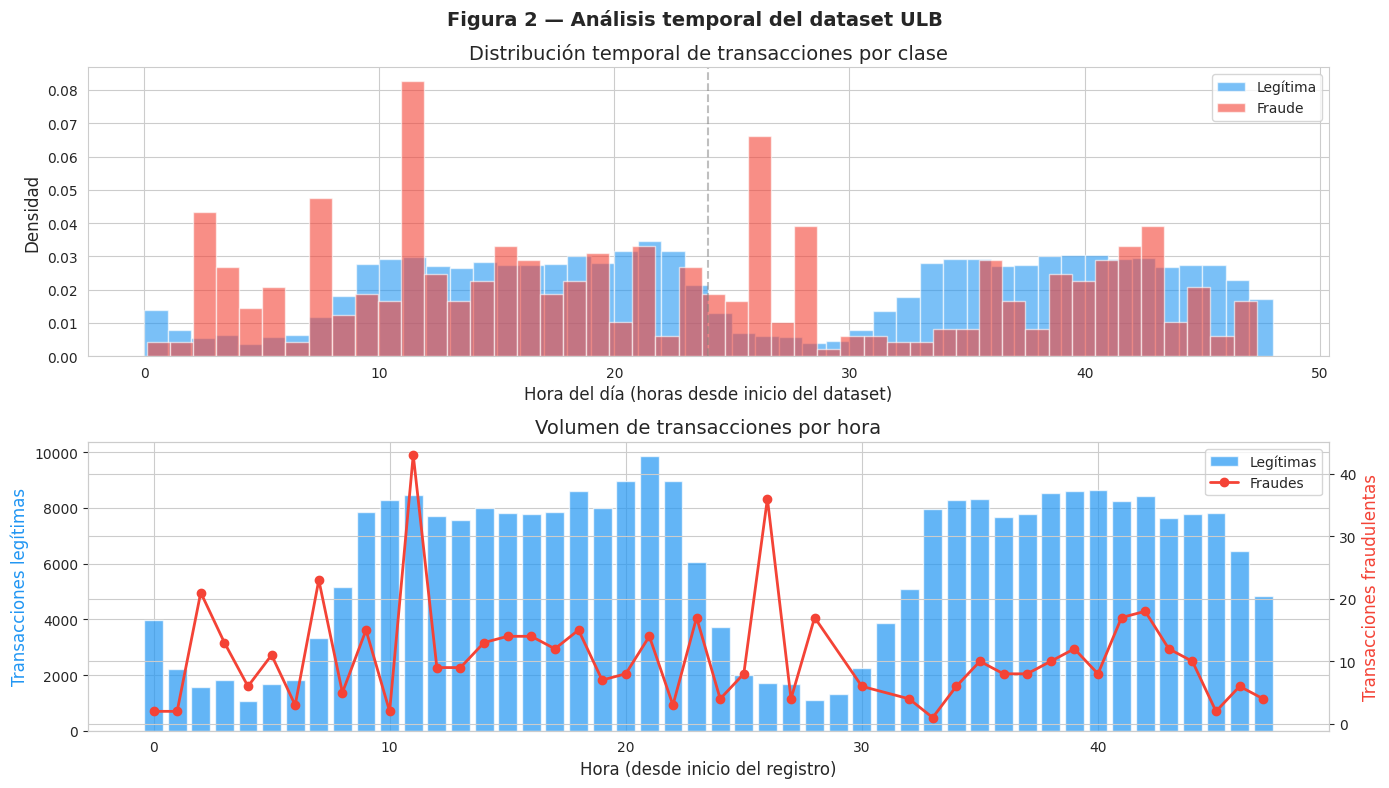

✅ Figura guardada: fig02_distribucion_temporal.png

Rango temporal: 0 – 172792 segundos (48.0 horas)
Fraudes en primer día (0-24h):  281
Fraudes en segundo día (24-48h): 211


In [11]:
# ── ANÁLISIS DE LA VARIABLE TIME ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Distribución por clase
for cls, color, label in [(0, '#2196F3', 'Legítima'), (1, '#F44336', 'Fraude')]:
    axes[0].hist(df[df['Class']==cls]['Time'] / 3600,
                 bins=48, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('Hora del día (horas desde inicio del dataset)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución temporal de transacciones por clase')
axes[0].legend()
axes[0].axvline(x=24, color='gray', linestyle='--', alpha=0.5, label='24h (inicio día 2)')

# Volumen por hora
df['Hour'] = (df['Time'] // 3600).astype(int)
hourly_leg  = df[df['Class']==0].groupby('Hour').size()
hourly_fraud = df[df['Class']==1].groupby('Hour').size()

ax2 = axes[1]
ax2.bar(hourly_leg.index, hourly_leg.values, color='#2196F3', alpha=0.7, label='Legítimas')
ax2_twin = ax2.twinx()
ax2_twin.plot(hourly_fraud.index, hourly_fraud.values, color='#F44336',
              marker='o', linewidth=2, label='Fraudes')
ax2.set_xlabel('Hora (desde inicio del registro)')
ax2.set_ylabel('Transacciones legítimas', color='#2196F3')
ax2_twin.set_ylabel('Transacciones fraudulentas', color='#F44336')
ax2.set_title('Volumen de transacciones por hora')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('Figura 2 — Análisis temporal del dataset ULB', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig02_distribucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: fig02_distribucion_temporal.png")

# Estadísticas
print(f"\nRango temporal: {df['Time'].min():.0f} – {df['Time'].max():.0f} segundos ({df['Time'].max()/3600:.1f} horas)")
print(f"Fraudes en primer día (0-24h):  {df[(df['Class']==1) & (df['Hour']<24)].shape[0]}")
print(f"Fraudes en segundo día (24-48h): {df[(df['Class']==1) & (df['Hour']>=24)].shape[0]}")


## 4. Distribución del importe (variable Amount)

=== ESTADÍSTICAS DE AMOUNT POR CLASE ===
Métrica               Legítimas    Fraudulentas
----------------------------------------------
Media                     88.29          122.21
Mediana                   22.00            9.25
Desv. estándar           250.10          256.42
Mínimo                     0.00            0.00
Máximo                 25691.16         2125.87


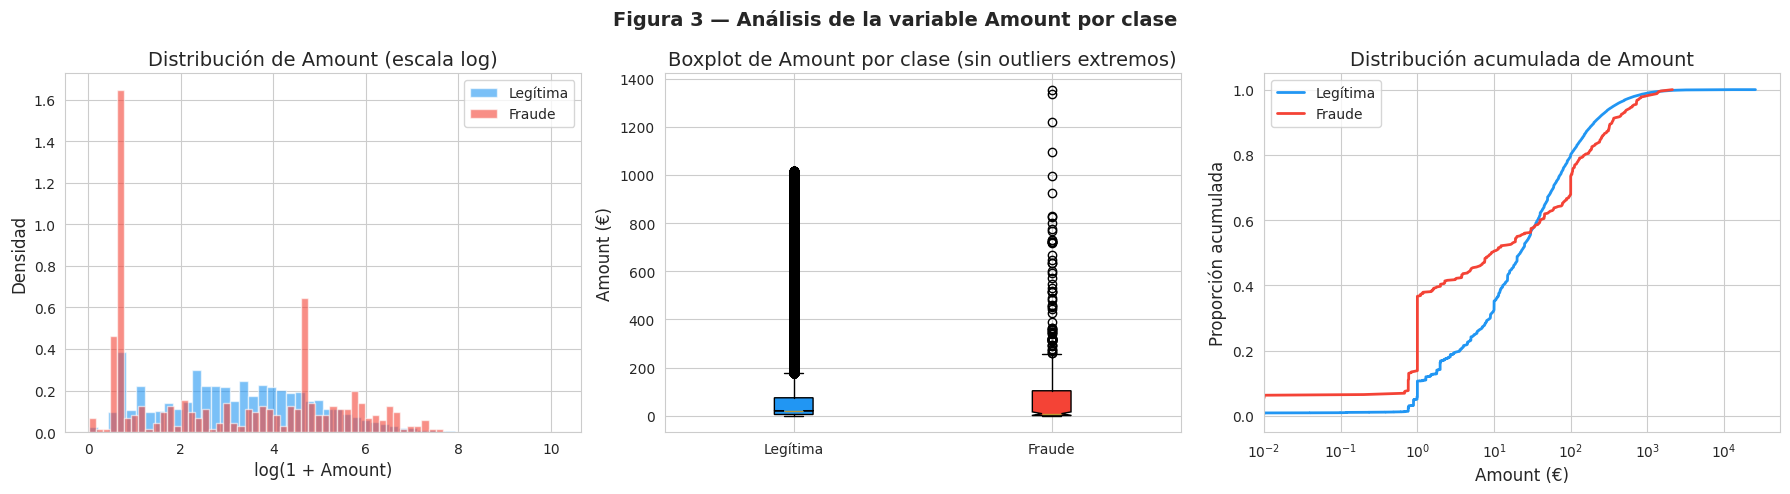

✅ Figura guardada: fig03_distribucion_amount.png


In [12]:
# ── ANÁLISIS DE LA VARIABLE AMOUNT ───────────────────────────────────────
fraud_amt  = df[df['Class']==1]['Amount']
legit_amt  = df[df['Class']==0]['Amount']

print("=== ESTADÍSTICAS DE AMOUNT POR CLASE ===")
print(f"{'Métrica':<15} {'Legítimas':>15} {'Fraudulentas':>15}")
print("-" * 46)
for fn, name in [(np.mean,'Media'), (np.median,'Mediana'), (np.std,'Desv. estándar'),
                 (np.min,'Mínimo'), (np.max,'Máximo')]:
    print(f"{name:<15} {fn(legit_amt):>15.2f} {fn(fraud_amt):>15.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma en escala log
for cls, color, label in [(0,'#2196F3','Legítima'), (1,'#F44336','Fraude')]:
    data = df[df['Class']==cls]['Amount']
    data_nonzero = data[data > 0]
    axes[0].hist(np.log1p(data_nonzero), bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('log(1 + Amount)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Amount (escala log)')
axes[0].legend()

# Boxplot comparativo
bp_data = [legit_amt[legit_amt <= legit_amt.quantile(0.99)],
           fraud_amt[fraud_amt <= fraud_amt.quantile(0.99)]]
bp = axes[1].boxplot(bp_data, labels=['Legítima', 'Fraude'],
                     patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#F44336')
axes[1].set_ylabel('Amount (€)')
axes[1].set_title('Boxplot de Amount por clase (sin outliers extremos)')

# Percentiles acumulados
for cls, color, label in [(0,'#2196F3','Legítima'), (1,'#F44336','Fraude')]:
    data = np.sort(df[df['Class']==cls]['Amount'].values)
    axes[2].plot(data, np.linspace(0, 1, len(data)), color=color, label=label, linewidth=2)
axes[2].set_xlabel('Amount (€)')
axes[2].set_xscale('log')
axes[2].set_ylabel('Proporción acumulada')
axes[2].set_title('Distribución acumulada de Amount')
axes[2].legend()
axes[2].set_xlim(left=0.01)

plt.suptitle('Figura 3 — Análisis de la variable Amount por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig03_distribucion_amount.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: fig03_distribucion_amount.png")


## 5. Análisis de las variables PCA (V1–V28)

In [13]:
# ── DISTRIBUCIÓN DE VARIABLES PCA ────────────────────────────────────────
pca_vars = [f'V{i}' for i in range(1, 29)]

# Estadísticas por clase
print("=== MEDIAS DE VARIABLES PCA POR CLASE ===")
means = pd.DataFrame({
    'Legítima (0)' : df[df['Class']==0][pca_vars].mean(),
    'Fraude (1)'   : df[df['Class']==1][pca_vars].mean(),
})
means['Diferencia'] = (means['Fraude (1)'] - means['Legítima (0)']).abs()
means['|Diff| rank'] = means['Diferencia'].rank(ascending=False).astype(int)
print(means.sort_values('Diferencia', ascending=False).to_string())


=== MEDIAS DE VARIABLES PCA POR CLASE ===
     Legítima (0)  Fraude (1)  Diferencia  |Diff| rank
V3       0.012171   -7.033281    7.045452            1
V14      0.012064   -6.971723    6.983787            2
V17      0.011535   -6.665836    6.677371            3
V12      0.010832   -6.259393    6.270225            4
V10      0.009824   -5.676883    5.686707            5
V7       0.009637   -5.568731    5.578368            6
V1       0.008258   -4.771948    4.780206            7
V4      -0.007860    4.542029    4.549889            8
V16      0.007164   -4.139946    4.147110            9
V11     -0.006576    3.800173    3.806749           10
V2      -0.006271    3.623778    3.630049           11
V5       0.005453   -3.151225    3.156678           12
V9       0.004467   -2.581123    2.585589           13
V18      0.003887   -2.246308    2.250195           14
V6       0.002419   -1.397737    1.400155           15
V21     -0.001235    0.713588    0.714823           16
V19     -0.001178    0.

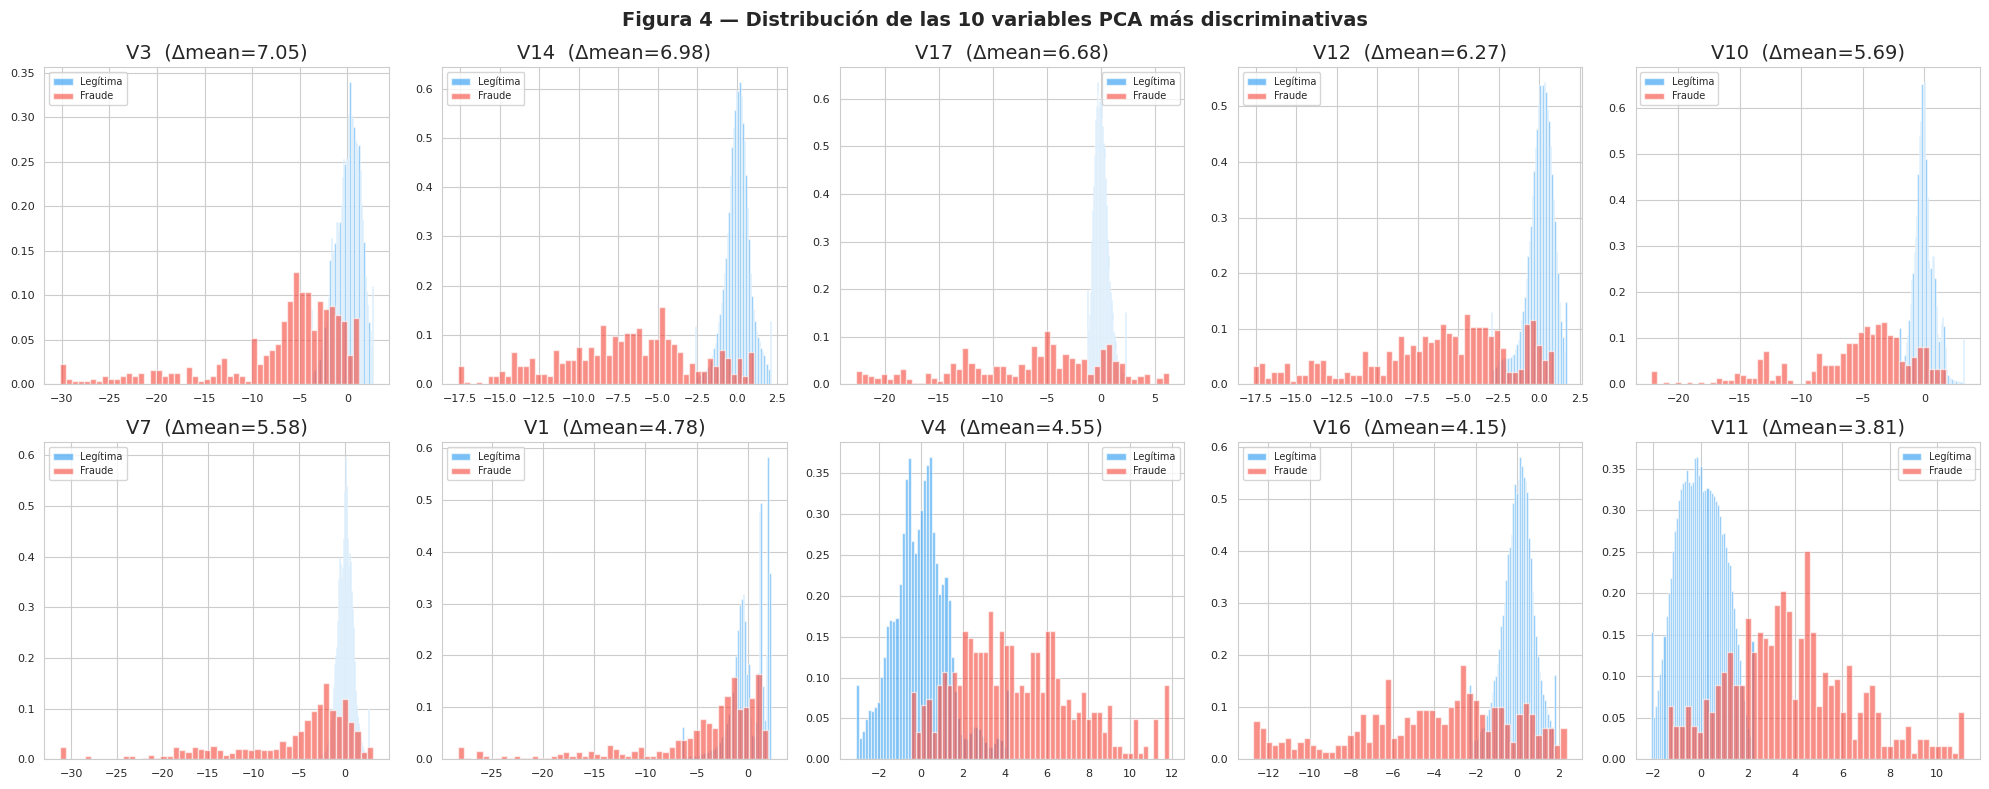

✅ Figura guardada: fig04_top10_variables_pca.png

Top 10 variables más discriminativas: ['V3', 'V14', 'V17', 'V12', 'V10', 'V7', 'V1', 'V4', 'V16', 'V11']


In [14]:
# ── TOP 10 VARIABLES MÁS DISCRIMINATIVAS ─────────────────────────────────
top10 = means.sort_values('Diferencia', ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, var in enumerate(top10):
    for cls, color, label in [(0,'#2196F3','Legítima'), (1,'#F44336','Fraude')]:
        data = df[df['Class']==cls][var]
        q01, q99 = data.quantile(0.01), data.quantile(0.99)
        data_clip = data.clip(q01, q99)
        axes[i].hist(data_clip, bins=50, alpha=0.6, color=color,
                     label=label, density=True)
    axes[i].set_title(f'{var}  (Δmean={means.loc[var,"Diferencia"]:.2f})')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Figura 4 — Distribución de las 10 variables PCA más discriminativas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig04_top10_variables_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: fig04_top10_variables_pca.png")
print(f"\nTop 10 variables más discriminativas: {top10}")


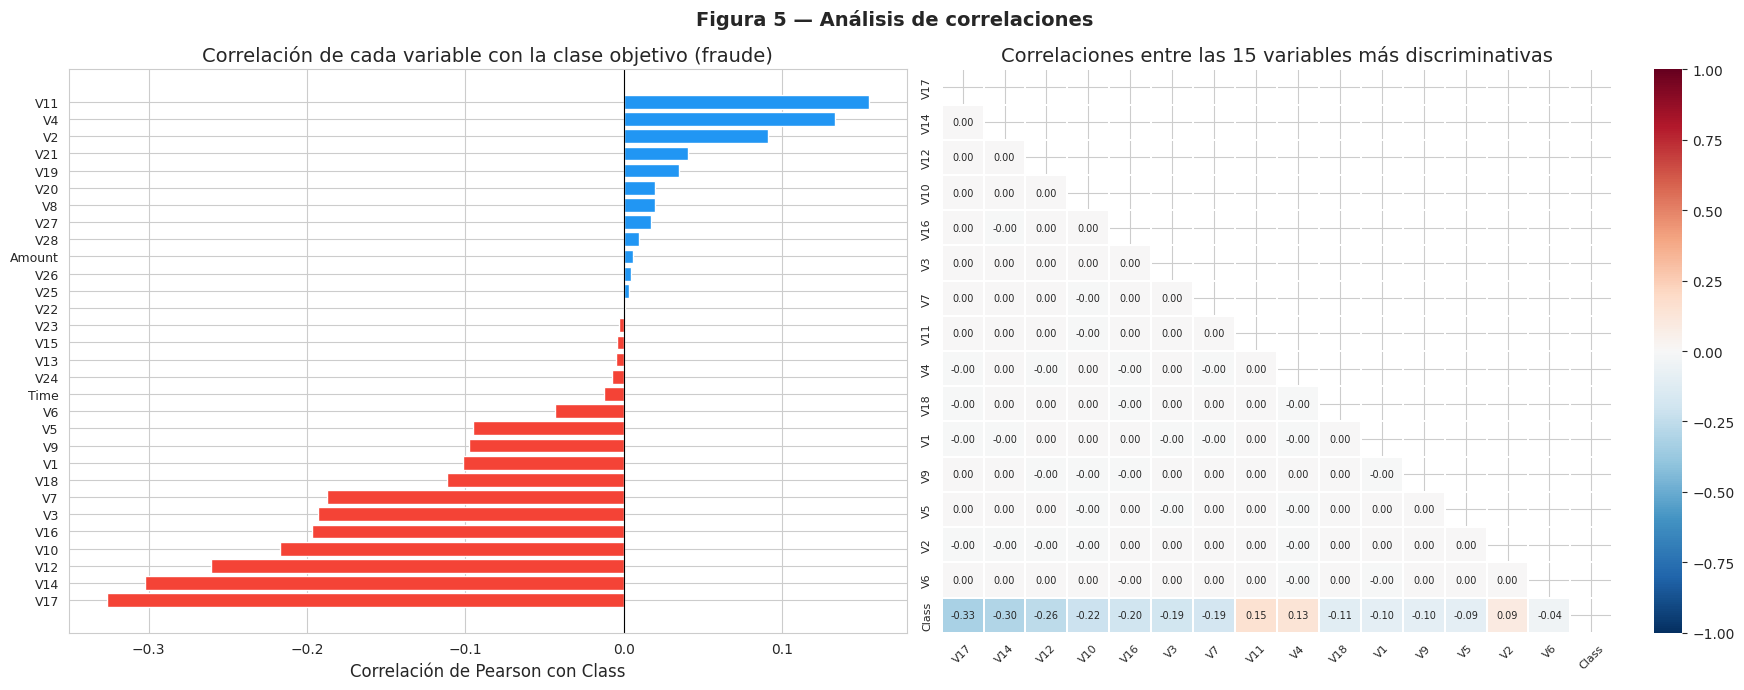

✅ Figura guardada: fig05_correlaciones.png


In [15]:
# ── HEATMAP DE CORRELACIONES ─────────────────────────────────────────────
# Correlación con la clase objetivo
corr_with_class = df[pca_vars + ['Amount','Time','Class']].corr()['Class'].drop('Class').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barras de correlación con Class
colors = ['#F44336' if v < 0 else '#2196F3' for v in corr_with_class.values]
axes[0].barh(corr_with_class.index, corr_with_class.values, color=colors, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlación de Pearson con Class')
axes[0].set_title('Correlación de cada variable con la clase objetivo (fraude)')
axes[0].tick_params(axis='y', labelsize=9)

# Heatmap de correlaciones entre las top variables
top_vars = corr_with_class.abs().sort_values(ascending=False).head(15).index.tolist() + ['Class']
corr_matrix = df[top_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1], mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, vmin=-1, vmax=1)
axes[1].set_title('Correlaciones entre las 15 variables más discriminativas')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Figura 5 — Análisis de correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig05_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: fig05_correlaciones.png")


## 6. Detección de outliers en variables clave

=== OUTLIERS (Z-score > 3) POR CLASE ===
  V14 | Clase 0:  3731 outliers  (1.31%)
  V14 | Clase 1:     0 outliers  (0.00%)
  V17 | Clase 0:  3121 outliers  (1.10%)
  V17 | Clase 1:     0 outliers  (0.00%)
  V12 | Clase 0:  4230 outliers  (1.49%)
  V12 | Clase 1:     0 outliers  (0.00%)
  V10 | Clase 0:  3398 outliers  (1.20%)
  V10 | Clase 1:     8 outliers  (1.63%)
  Amount | Clase 0:  4066 outliers  (1.43%)
  Amount | Clase 1:    11 outliers  (2.24%)


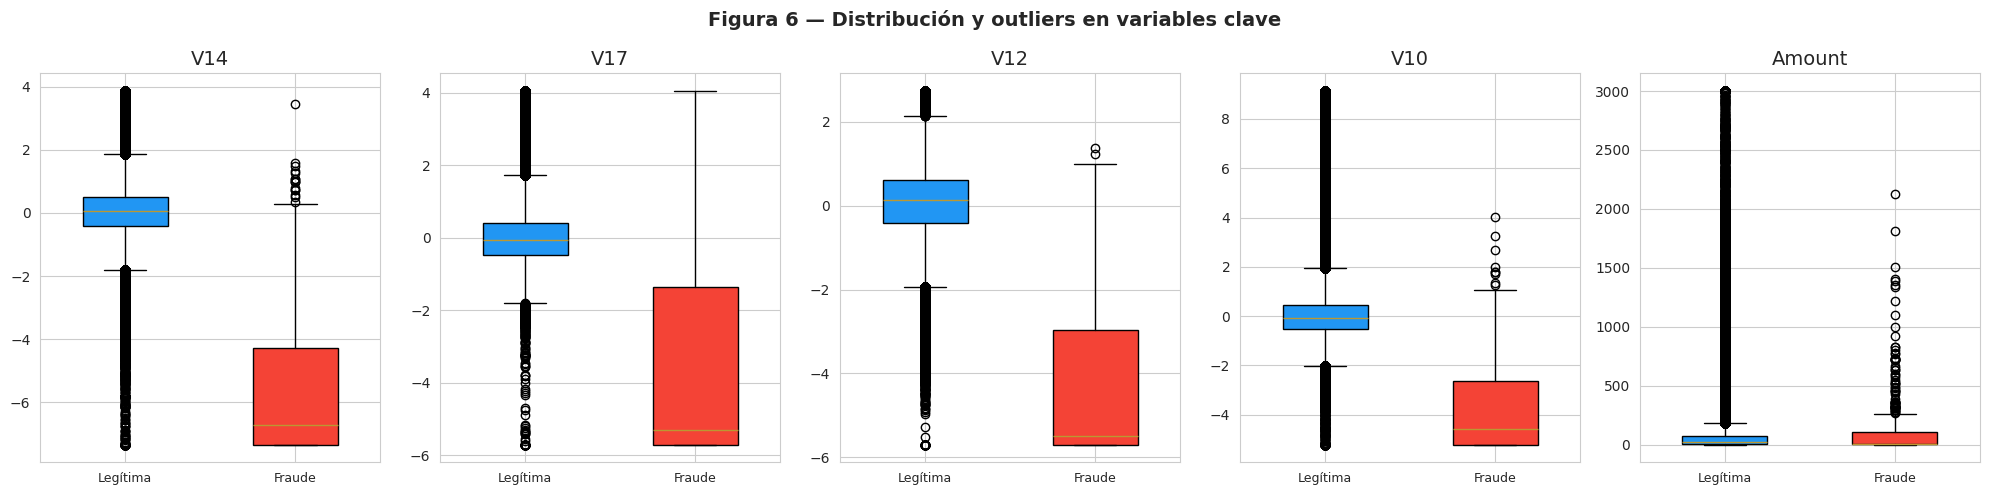

✅ Figura guardada: fig06_outliers.png


In [16]:
# ── ANÁLISIS DE OUTLIERS ──────────────────────────────────────────────────
# Variables más discriminativas para analizar outliers
vars_outlier = ['V14', 'V17', 'V12', 'V10', 'Amount']

print("=== OUTLIERS (Z-score > 3) POR CLASE ===")
for var in vars_outlier:
    for cls in [0, 1]:
        data = df[df['Class']==cls][var]
        z    = np.abs(stats.zscore(data))
        n_out = (z > 3).sum()
        print(f"  {var} | Clase {cls}: {n_out:>5} outliers  ({n_out/len(data)*100:.2f}%)")

fig, axes = plt.subplots(1, len(vars_outlier), figsize=(20, 5))
for i, var in enumerate(vars_outlier):
    bp = axes[i].boxplot(
        [df[df['Class']==0][var].clip(df[var].quantile(0.001), df[var].quantile(0.999)),
         df[df['Class']==1][var].clip(df[var].quantile(0.001), df[var].quantile(0.999))],
        labels=['Legítima', 'Fraude'],
        patch_artist=True, notch=False, widths=0.5
    )
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#F44336')
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', labelsize=9)

plt.suptitle('Figura 6 — Distribución y outliers en variables clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig06_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: fig06_outliers.png")


## 7. Resumen ejecutivo del EDA

In [17]:
# ── TABLA RESUMEN PARA EL TFM ─────────────────────────────────────────────
print("=" * 60)
print("RESUMEN EJECUTIVO DEL EDA — Dataset ULB")
print("=" * 60)
print(f"  Total transacciones   : {len(df):>10,}")
print(f"  Transacciones legítimas: {class_counts[0]:>10,}  ({class_pct[0]:.3f}%)")
print(f"  Transacciones fraude  : {class_counts[1]:>10,}  ({class_pct[1]:.3f}%)")
print(f"  Ratio desbalance      : {class_counts[0]/class_counts[1]:>10.0f}:1")
print()
print(f"  Variables totales     : {df.shape[1]:>10}")
print(f"  Variables PCA (V1-V28): {28:>10}")
print(f"  Variables sin PCA     : {'Time, Amount':>10}")
print(f"  Variable objetivo     : {'Class':>10}")
print(f"  Valores faltantes     : {df.isnull().sum().sum():>10}")
print()
print(f"  Rango temporal        : {df['Time'].max()/3600:.1f} horas (~2 días)")
print(f"  Amount — media legít. : {legit_amt.mean():>10.2f} €")
print(f"  Amount — media fraude : {fraud_amt.mean():>10.2f} €")
print(f"  Amount — mediana legít: {legit_amt.median():>10.2f} €")
print(f"  Amount — mediana fraude: {fraud_amt.median():>9.2f} €")
print()
top3 = means.sort_values('Diferencia', ascending=False).head(3).index.tolist()
print(f"  Top 3 variables discriminativas: {', '.join(top3)}")
print()
print("Figuras generadas:")
figs = ['fig01_distribucion_clases.png', 'fig02_distribucion_temporal.png',
        'fig03_distribucion_amount.png', 'fig04_top10_variables_pca.png',
        'fig05_correlaciones.png', 'fig06_outliers.png']
for f in figs:
    print(f"  ✅ {f}")
print()
print("✅ EDA completado. Copia estos resultados y figuras para el TFM.")


RESUMEN EJECUTIVO DEL EDA — Dataset ULB
  Total transacciones   :    284,807
  Transacciones legítimas:    284,315  (99.827%)
  Transacciones fraude  :        492  (0.173%)
  Ratio desbalance      :        578:1

  Variables totales     :         32
  Variables PCA (V1-V28):         28
  Variables sin PCA     : Time, Amount
  Variable objetivo     :      Class
  Valores faltantes     :          0

  Rango temporal        : 48.0 horas (~2 días)
  Amount — media legít. :      88.29 €
  Amount — media fraude :     122.21 €
  Amount — mediana legít:      22.00 €
  Amount — mediana fraude:      9.25 €

  Top 3 variables discriminativas: V3, V14, V17

Figuras generadas:
  ✅ fig01_distribucion_clases.png
  ✅ fig02_distribucion_temporal.png
  ✅ fig03_distribucion_amount.png
  ✅ fig04_top10_variables_pca.png
  ✅ fig05_correlaciones.png
  ✅ fig06_outliers.png

✅ EDA completado. Copia estos resultados y figuras para el TFM.
